### Importación de datos



In [7]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359



# Limpieza de datos




In [12]:
urls = {
    'tienda': url,
    'tienda_2': url2,
    'tienda_3': url3,
    'tienda_4': url4
}


lista_dfs = []

for nombre_tienda, url in urls.items():
  df_temp = pd.read_csv(url)
  df_temp['Nombre_tienda']=nombre_tienda
  lista_dfs.append(df_temp)

df_master = pd.concat(lista_dfs, ignore_index=True)
print(df_master.shape)
df_master.head()

(9434, 13)


,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon,Nombre_tienda
0,Lavavajillas,Electrodomésticos,1084800.0,56000.0,11/11/2022,Rafael Acosta,Bogotá,4,Tarjeta de crédito,3,4.60971,-74.08175,tienda
1,Cama box,Muebles,473800.0,25400.0,03/01/2020,Izabela de León,Cúcuta,5,Tarjeta de crédito,2,7.89391,-72.50782,tienda
2,Balón de baloncesto,Deportes y diversión,23700.0,0.0,25/12/2022,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359,tienda
3,Modelado predictivo,Libros,57700.0,1300.0,23/11/2021,Lucas Olivera,Medellín,3,Nequi,1,6.25184,-75.56359,tienda
4,Auriculares,Electrónicos,138900.0,5600.0,25/04/2022,Blanca Ramirez,Bogotá,4,Tarjeta de crédito,7,4.60971,-74.08175,tienda


In [13]:
df_master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9434 entries, 0 to 9433
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Producto                9434 non-null   object 
 1   Categoría del Producto  9434 non-null   object 
 2   Precio                  9434 non-null   float64
 3   Costo de envío          9434 non-null   float64
 4   Fecha de Compra         9434 non-null   object 
 5   Vendedor                9434 non-null   object 
 6   Lugar de Compra         9434 non-null   object 
 7   Calificación            9434 non-null   int64  
 8   Método de pago          9434 non-null   object 
 9   Cantidad de cuotas      9434 non-null   int64  
 10  lat                     9434 non-null   float64
 11  lon                     9434 non-null   float64
 12  Nombre_tienda           9434 non-null   object 
dtypes: float64(4), int64(2), object(7)
memory usage: 958.3+ KB


In [14]:
df_master.describe()

,Precio,Costo de envío,Calificación,Cantidad de cuotas,lat,lon
count,9.434000e+03,9434.000000,9434.000000,9434.000000,9434.000000,9434.000000
mean,4.548563e+05,24235.372059,4.019292,2.915624,5.440973,-74.756401
std,5.786315e+05,30822.566127,1.387289,2.780550,2.377423,1.202549
min,7.600000e+03,0.000000,1.000000,1.000000,-4.215280,-77.281110
25%,5.450000e+04,2900.000000,4.000000,1.000000,4.609710,-75.563590
50%,2.144000e+05,11400.000000,5.000000,1.000000,4.609710,-74.199040
75%,6.477250e+05,34300.000000,5.000000,4.000000,6.251840,-74.081750
max,2.968200e+06,162500.000000,5.000000,24.000000,11.544440,-67.923900


In [19]:
df_master['Fecha de Compra'] = pd.to_datetime(df_master['Fecha de Compra'], dayfirst=True)

In [21]:
df_master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9434 entries, 0 to 9433
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Producto                9434 non-null   object        
 1   Categoría del Producto  9434 non-null   object        
 2   Precio                  9434 non-null   float64       
 3   Costo de envío          9434 non-null   float64       
 4   Fecha de Compra         9434 non-null   datetime64[ns]
 5   Vendedor                9434 non-null   object        
 6   Lugar de Compra         9434 non-null   object        
 7   Calificación            9434 non-null   int64         
 8   Método de pago          9434 non-null   object        
 9   Cantidad de cuotas      9434 non-null   int64         
 10  lat                     9434 non-null   float64       
 11  lon                     9434 non-null   float64       
 12  Nombre_tienda           9434 non-null   object  

#1. Análisis de facturación



In [64]:
ingresos_df = df_master.groupby('Nombre_tienda')['Precio'].sum().sort_values(ascending=False).reset_index()
ingresos_df

,Nombre_tienda,Precio
0,tienda_2,1.116344e+09
1,tienda_3,1.098020e+09
2,tienda,1.038376e+09
3,tienda_4,1.038376e+09


# 2. Ventas por categoría

In [37]:
ventas_por_categoria = df_master.groupby(['Nombre_tienda', 'Categoría del Producto']).size().reset_index(name='Total_Ventas')
ventas_por_categoria

,Nombre_tienda,Categoría del Producto,Total_Ventas
0,tienda,Artículos para el hogar,201
1,tienda,Deportes y diversión,277
2,tienda,Electrodomésticos,254
3,tienda,Electrónicos,451
4,tienda,Instrumentos musicales,170
5,tienda,Juguetes,338
6,tienda,Libros,187
7,tienda,Muebles,480
8,tienda_2,Artículos para el hogar,181
9,tienda_2,Deportes y diversión,275


In [38]:
ventas_por_categoria = ventas_por_categoria.sort_values(by=['Nombre_tienda', 'Total_Ventas'], ascending=[True, False])
ventas_por_categoria

,Nombre_tienda,Categoría del Producto,Total_Ventas
7,tienda,Muebles,480
3,tienda,Electrónicos,451
5,tienda,Juguetes,338
1,tienda,Deportes y diversión,277
2,tienda,Electrodomésticos,254
0,tienda,Artículos para el hogar,201
6,tienda,Libros,187
4,tienda,Instrumentos musicales,170
15,tienda_2,Muebles,442
11,tienda_2,Electrónicos,422


# 3. Calificación promedio de la tienda


In [41]:
valoracion_por_tienda = df_master.groupby('Nombre_tienda')['Calificación'].mean().round(2).sort_values(ascending=False).reset_index(name='Calificación_Promedio')
valoracion_por_tienda

,Nombre_tienda,Calificación_Promedio
0,tienda_3,4.05
1,tienda_2,4.04
2,tienda,4.00
3,tienda_4,4.00


# 4. Productos más y menos vendidos

In [51]:
ventas_por_producto = df_master.groupby(['Nombre_tienda', 'Producto']).size().reset_index(name='Total_Ventas')
ventas_por_producto

,Nombre_tienda,Producto,Total_Ventas
0,tienda,Ajedrez de madera,39
1,tienda,Armario,34
2,tienda,Asistente virtual,50
3,tienda,Auriculares,44
4,tienda,Auriculares con micrófono,42
...,...,...,...
199,tienda_4,Smartwatch,39
200,tienda_4,Sofá reclinable,47
201,tienda_4,TV LED UHD 4K,40
202,tienda_4,Tablet ABXY,45


In [52]:
ventas_por_producto = ventas_por_producto.sort_values(by=['Nombre_tienda', 'Total_Ventas'], ascending=[True, False])
ventas_por_producto

,Nombre_tienda,Producto,Total_Ventas
10,tienda,Cama box,62
15,tienda,Cubertería,59
11,tienda,Cama king,56
18,tienda,Dashboards con Power BI,56
12,tienda,Carrito de control remoto,55
...,...,...,...
181,tienda_4,Lavadora de ropa,38
192,tienda_4,Refrigerador,38
174,tienda_4,Guitarra acústica,37
154,tienda_4,Armario,34


In [55]:
top_3_productos = ventas_por_producto.groupby('Nombre_tienda').head(3)
top_3_productos

,Nombre_tienda,Producto,Total_Ventas
10,tienda,Cama box,62
15,tienda,Cubertería,59
11,tienda,Cama king,56
75,tienda_2,Iniciando en programación,65
84,tienda_2,Microondas,62
58,tienda_2,Batería,61
129,tienda_3,Kit de bancas,57
113,tienda_3,Cama king,56
133,tienda_3,Mesa de comedor,56
163,tienda_4,Cama box,62


# 5. Envío promedio por tienda

In [46]:
envio_promedio_por_tienda = df_master.groupby('Nombre_tienda')['Costo de envío'].mean().round(2).sort_values(ascending=False).reset_index(name='Costo_Envío_Promedio')
envio_promedio_por_tienda

,Nombre_tienda,Costo_Envío_Promedio
0,tienda_2,25216.24
1,tienda_3,24805.68
2,tienda,23459.46
3,tienda_4,23459.46


#**Visualización**

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid",palette="muted")



In [68]:
ingresos_df['Ingreso_Millones'] = ingresos_df['Precio'] / 1000000

##1. Gráfico de barras de los ingresos brutos por tienda

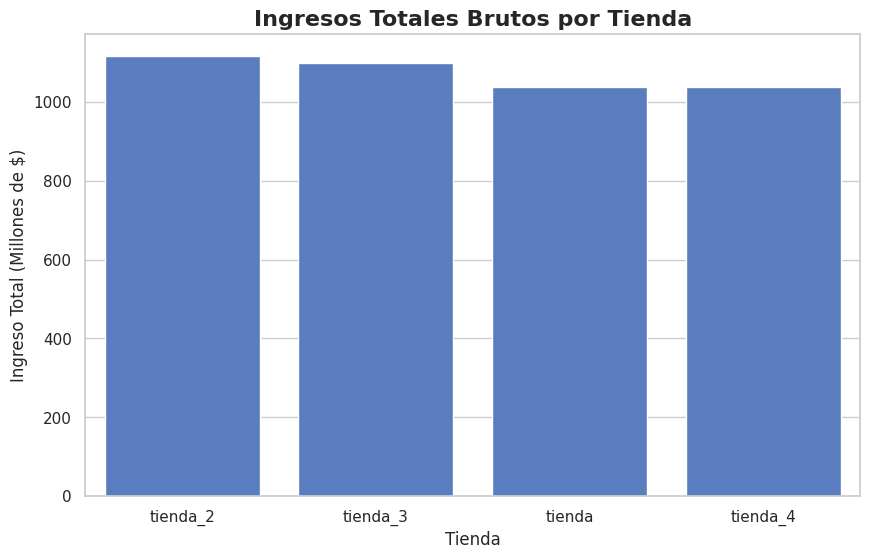

In [72]:
plt.figure(figsize=(10,6))

sns.barplot(data=ingresos_df, x='Nombre_tienda', y='Ingreso_Millones')
plt.title('Ingresos Totales Brutos por Tienda', fontsize=16, fontweight='bold')
plt.xlabel('Tienda', fontsize=12)
plt.ylabel('Ingreso Total (Millones de $)', fontsize=12)

plt.show()

##2. Gráfico de caja sobre los costos de envio por tienda

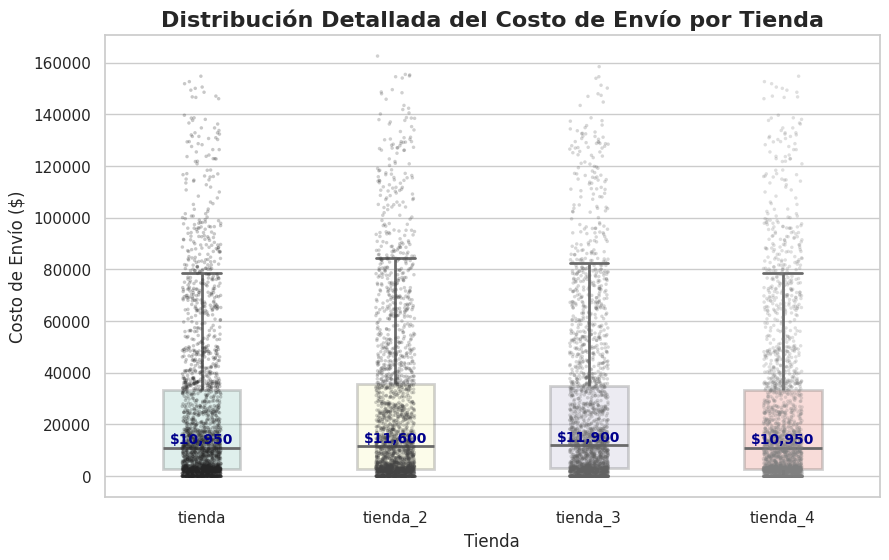

In [84]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df_master, x='Nombre_tienda', y='Costo de envío',
            hue='Nombre_tienda',
            palette='Set3',
            legend=False,
            showfliers=False,
            width=0.4,
            linewidth=2,
            boxprops={'alpha': 0.3})

sns.stripplot(data=df_master, x='Nombre_tienda', y='Costo de envío',
              hue='Nombre_tienda', palette="dark:grey", size=2.5,
              legend=False, jitter=True, alpha=0.25)

medianas = df_master.groupby('Nombre_tienda')['Costo de envío'].median().values
posiciones_x = np.arange(len(medianas))

for i, mediana in enumerate(medianas):
  plt.text(posiciones_x[i],mediana + 500,
           f'${int(mediana):,}', ha='center',va='bottom', fontsize=10,
           fontweight='bold', color='darkblue')

plt.title('Distribución Detallada del Costo de Envío por Tienda',
          fontsize=16, fontweight='bold')
plt.xlabel('Tienda', fontsize=12)
plt.ylabel('Costo de Envío ($)', fontsize=12)

plt.show()

##3. Gráfico de Dispersión relación precio producto - costo de envio

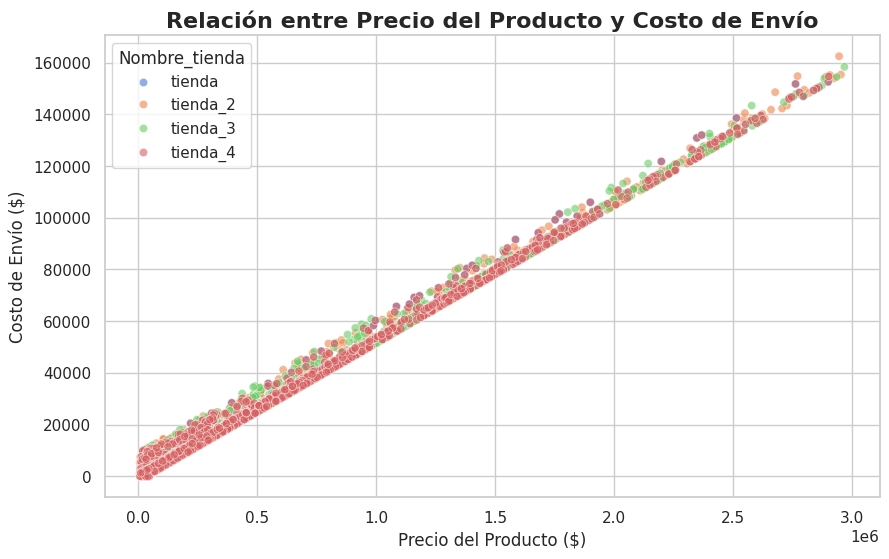

In [85]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df_master, x='Precio', y='Costo de envío', hue='Nombre_tienda', alpha=0.6)

plt.title('Relación entre Precio del Producto y Costo de Envío', fontsize=16, fontweight='bold')
plt.xlabel('Precio del Producto ($)', fontsize=12)
plt.ylabel('Costo de Envío ($)', fontsize=12)

plt.show()


#**Reporte Final y recomendación**

Tras el análissi de los datos de las cuatro sucursales, la recomendacion final para financiasr el nuevo proyecto es proceder con la venta de la **Tienda 4.**

Esta decisión esta fundamenta en los siguientes puntos clave:


*   Menor rendimiento financiero: La Tienda 4 registra el volumen de facturación bruta más bajo de toda la cadena, aportando el menor valor económico al negocio.

*   Foco rojo en la satisfacción del cliente: Presenta la valoración promedio más baja por parte de los compradores.

*   Estandarización logística: Si bien los costos operativos de envío varían, nuestro análisis de dispersión demostró que todas las sucursales siguen exactamente el mismo modelo estandarizado de cobro. Por lo tanto, ninguna tienda tiene una "ventaja" o "desventaja" real que justifique retener a la Tienda 4.

